In [1]:
# 导入必要的库
import torch  # PyTorch深度学习框架
import torch.nn as nn  # 神经网络模块
import torch.optim as optim  # 优化器
import torchvision  # 计算机视觉工具包
import torchvision.transforms as transforms  # 数据转换和增强
from torch.utils.data import DataLoader  # 数据加载器
from tqdm import tqdm  # 进度条
import matplotlib.pyplot as plt  # 绘图工具

# 检测并设置计算设备（GPU/CPU）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
def get_data_loaders(batch_size=128):
    # 定义训练集的数据增强和预处理流程
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),  # 随机裁剪，增加模型鲁棒性
        transforms.RandomHorizontalFlip(),  # 随机水平翻转
        transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 亮度和对比度增强
        transforms.RandomRotation(15),  # 随机旋转
        transforms.ToTensor(),  # 转换为张量
        transforms.Normalize((0.4914, 0.4822, 0.4465),  # CIFAR10数据集的标准化参数
                           (0.2023, 0.1994, 0.2010))
    ])
    
    # 定义测试集的数据预处理流程（不需要数据增强）
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), 
                           (0.2023, 0.1994, 0.2010))
    ])
    
    # 加载CIFAR10训练集
    # trainset = torchvision.datasets.CIFAR10(
    #     root='./data', train=True, download=True, transform=transform_train)
    # 示例：CIFAR10子集（10%数据）
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    subset_indices = torch.randperm(len(trainset))[:int(0.1 * len(trainset))] # 随机取10%
    trainset = torch.utils.data.Subset(trainset, subset_indices)
    trainloader = DataLoader(
        trainset, batch_size=batch_size, shuffle=True, 
        num_workers=2, pin_memory=True)  # 启用pin_memory加速数据传输
    
    # 加载CIFAR10测试集
    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test)
    testloader = DataLoader(
        testset, batch_size=batch_size, shuffle=False, 
        num_workers=2, pin_memory=True)
    
    return trainloader, testloader

In [5]:
def get_model():
    # 加载预训练的ResNet18模型
    model = torchvision.models.resnet18(pretrained=True)
    
    # 选择性解冻层：只训练layer3、layer4和fc层
    # for name, param in model.named_parameters():
    #     if "layer3" in name or "layer4" in name or "fc" in name:
    #         param.requires_grad = True  # 这些层将参与训练
    #     else:
    #         param.requires_grad = False  # 其他层保持冻结
    
    # 修改第一个卷积层以适应CIFAR10的32x32输入尺寸
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()  # 移除maxpool层，因为输入图像较小
    
    # 重新设计分类器结构
    model.fc = nn.Sequential(
        nn.Linear(512, 256),  # 降维
        nn.BatchNorm1d(256),  # 批归一化提升训练稳定性
        nn.ReLU(),  # 激活函数
        nn.Dropout(0.5),  # dropout防止过拟合
        nn.Linear(256, 10)  # 输出层，10个类别
    )
    
    return model.to(device)  # 将模型转移到指定设备

In [6]:
def train_epoch(model, trainloader, criterion, optimizer):
    model.train()  # 设置为训练模式
    running_loss = 0.0
    correct = 0
    total = 0
    
    # 使用tqdm显示训练进度
    pbar = tqdm(trainloader, desc='Training')
    for inputs, targets in pbar:
        # 将数据转移到指定设备
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()  # 清空梯度
        outputs = model(inputs)  # 前向传播
        loss = criterion(outputs, targets)  # 计算损失
        loss.backward()  # 反向传播
        
        # 梯度裁剪，防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()  # 更新参数
        
        # 统计训练指标
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
        # 更新进度条信息
        pbar.set_postfix({
            'loss': '%.3f' % (running_loss / (pbar.n + 1)),
            'acc': '%.3f%%' % (100. * correct / total)
        })
    
    return running_loss / len(trainloader), 100. * correct / total

In [7]:
@torch.no_grad()  # 禁用梯度计算
def evaluate(model, testloader, criterion):
    model.eval()  # 设置为评估模式
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, targets in testloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    return running_loss / len(testloader), 100. * correct / total

Files already downloaded and verified
Files already downloaded and verified


d:\miniconda3\envs\torch_cu124\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\miniconda3\envs\torch_cu124\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Epoch: 1/50


Training: 100%|██████████| 40/40 [00:54<00:00,  1.37s/it, loss=1.960, acc=28.340%]


Train Loss: 1.960 | Train Acc: 28.34%
Test Loss: 1.507 | Test Acc: 46.66%

Epoch: 2/50


...

Train Loss: 0.167 | Train Acc: 94.60%
Test Loss: 0.909 | Test Acc: 76.90%

Epoch: 39/50


Training: 100%|██████████| 40/40 [00:13<00:00,  3.04it/s, loss=0.198, acc=94.920%]


Train Loss: 0.193 | Train Acc: 94.92%
Test Loss: 0.913 | Test Acc: 76.98%

Epoch: 40/50


Training: 100%|██████████| 40/40 [00:13<00:00,  3.04it/s, loss=0.151, acc=95.240%]


Train Loss: 0.147 | Train Acc: 95.24%
Test Loss: 0.905 | Test Acc: 76.98%
Early stopping triggered


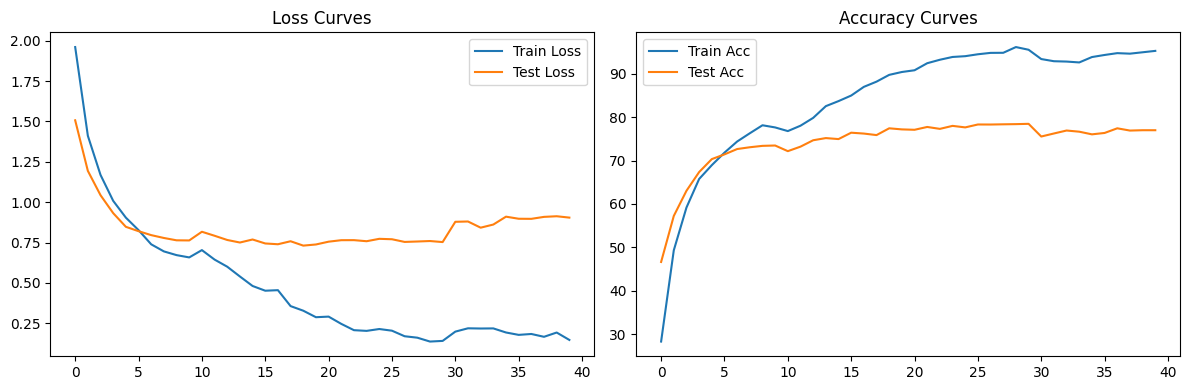

In [8]:
def main():
    # 设置训练超参数
    BATCH_SIZE = 128
    EPOCHS = 50
    LR = 0.001
    
    # 加载数据
    trainloader, testloader = get_data_loaders(BATCH_SIZE)
    model = get_model()
    
    # 定义损失函数和优化器
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW([
        {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 
         'lr': LR * 0.1},  # 主干网络使用较小学习率
        {'params': model.fc.parameters(), 'lr': LR}  # 分类器使用较大学习率
    ], weight_decay=1e-4)  # 添加L2正则化
    
    # 学习率调度器
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2)
    
    # 初始化记录器
    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []
    
    # 早停设置
    best_acc = 0
    patience = 10
    patience_counter = 0
    
    # 训练循环
    for epoch in range(EPOCHS):
        print(f'\nEpoch: {epoch+1}/{EPOCHS}')
        
        # 训练和评估
        train_loss, train_acc = train_epoch(
            model, trainloader, criterion, optimizer)
        test_loss, test_acc = evaluate(model, testloader, criterion)
        
        scheduler.step()  # 更新学习率
        
        # 记录指标
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        
        print(f'Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}%')
        print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc:.2f}%')
        
        # 模型保存和早停
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), 'best_model.pth')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stopping triggered')
                break
    
    # 绘制训练曲线
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.legend()
    plt.title('Loss Curves')
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(test_accs, label='Test Acc')
    plt.legend()
    plt.title('Accuracy Curves')
    
    plt.tight_layout()
    plt.savefig('training_curves.png')
    plt.show()

if __name__ == '__main__':
    main()